# Structural lesion network mapping

In this tutorial, you will explore the structural network mapping functionalities of Lacuna.

**What you'll learn**:

- Fetch a structural connectome
- Obtain voxel-level disconnectivity maps
- Compute a disconnectivity matrix
- Compute ROI-wise disconnection values

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/m-petersen/lacuna/blob/main/docs/tutorials/structural-network-mapping.ipynb)


## Colab

Note: Colab provides limited computational resources. While these tutorials are designed to operate within those constraints, some Lacuna functionality cannot be fully demonstrated in this environment and requires access to higher-performance computing infrastructure.

Ignore this if you run this notebook locally.

In [1]:
# --- Conda setup for Google Colab ---
# Lacuna's structural network mapping capabilities rely on MRtrix3.
# However, Colab does not include conda by default, which is required for MRtrix3 installation.
# We use condacolab to replace Colab's Python with a Mambaforge-based environment.
#
# IMPORTANT: Running this cell will RESTART the kernel automatically.
# After the restart, SKIP this cell and continue from the next cell onward.
# (Do NOT re-run this cell after the restart.)

import os

if os.environ.get("CONDA_PREFIX") is None:

    !pip install -q condacolab==0.1.9
    import condacolab
    condacolab.install()  # This restarts the kernel

In [2]:
# Run this after the kernel restart. 
import sys

if 'google.colab' in sys.modules:

    import condacolab
    import subprocess

    condacolab.check()

    conda_paths = subprocess.check_output(
        "python -c 'import sys; print(\"\\n\".join(sys.path))'", 
        shell=True, text=True
    ).split('\n')

    for path in conda_paths:
        if path and path not in sys.path:
            sys.path.append(path)
    
    print("Colab environment detected: condacolab initialized.")

## Setup

In [ ]:
# Install Lacuna from GitHub
!pip install git+https://github.com/m-petersen/lacuna

# Install MRtrix3 via conda
!conda install -c conda-forge -c MRtrix3 mrtrix3 libstdcxx-ng -y

# Install yabplot and pyvista for visualization
!pip install yabplot==0.4.0 pyvista==0.47.1

  Cloning https://github.com/m-petersen/lacuna to /tmp/pip-req-build-ph_5wlj6
  Running command git clone --filter=blob:none --quiet https://github.com/m-petersen/lacuna /tmp/pip-req-build-ph_5wlj6
  Resolved https://github.com/m-petersen/lacuna to commit 52aeb24b2df0ee5d0730c49bd5500dae2a312835
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Solving environment: | 
  - mrtrix3/linux-64::mrtrix3-3.0.8-h07fc403_0
  - MRtrix3/linux-64::mrtrix3-3.0.8-h07fc403done


==> WARNING: A newer version of conda exists. <==
  current version: 4.11.0
  latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.



Get the tutorial data.

In [1]:
!lacuna tutorial /tmp/tutorial_bids --force


Setting up tutorial data at: /tmp/tutorial_bids
✓ Tutorial data copied to: /tmp/tutorial_bids

The tutorial dataset includes:
  - 3 synthetic subjects (sub-01, sub-02, sub-03)
  - Binary lesion masks in MNI152NLin6Asym space
  - BIDS-style structure


Check whether mrtrix3 is properly installed as it is required for the analysis.

In [2]:
!mrinfo --version

== mrinfo 3.0.8 ==
64 bit release version, built Oct 21 2025, using Eigen 3.4.0
Author(s): J-Donald Tournier (jdtournier@gmail.com) and Robert E. Smith (robert.smith@florey.edu.au)
Copyright (c) 2008-2025 the MRtrix3 contributors.

This Source Code Form is subject to the terms of the Mozilla Public
License, v. 2.0. If a copy of the MPL was not distributed with this
file, You can obtain one at http://mozilla.org/MPL/2.0/.

Covered Software is provided under this License on an "as is"
basis, without warranty of any kind, either expressed, implied, or
statutory, including, without limitation, warranties that the
Covered Software is free of defects, merchantable, fit for a
particular purpose or non-infringing.
See the Mozilla Public License v. 2.0 for more details.

For more details, see http://www.mrtrix.org/.



## Fetch structural connectome

Structural network mapping requires a structural connectome in the form of a normative tractogram, i.e., a whole-brain reconstruction of white matter fiber pathways derived from diffusion-weighted MRI.

The main consideration when selecting a connectome is the trade-off between sensitivity and anatomical specificity.

Whenever possible, we recommend using [dTOR985]((https://springernature.figshare.com/articles/dataset/dTOR-985_structural_connectome_full_tractogram_trk_file/25209947)), as its extensive coverage maximizes sensitivity. This connectome was generated using an untargeted whole-brain tractography approach and contains approximately 11 million streamlines Downloading the full tractogram requires a personal [Figshare](https://figshare.com) API token. You can obtain one by logging into Figshare and navigating to Account → Integrations → Personal Tokens.

<p align="center">
  <img src="../assets/method_figures/dtor985.png" alt="dTOR985" style="width:100%; max-width:760px;"><br>
  <em style="font-size: 0.9em; color: #666;">dTOR985 normative tractogram</em>
</p>

For demonstration purposes, this tutorial uses a lightweight 10% random subsample of dTOR985, which can be downloaded without an API token and requires substantially fewer computational resources.

As an alternative, we can fetch the [HCP1065](https://brain.labsolver.org/hcp_trk_atlas.html) tractogram, which consists of a curated set of white matter bundles. It was generated using trajectory-based bundle recognition against an expert-vetted atlas, followed by topology-informed pruning to remove anatomically implausible connections. This results in higher anatomical specificity and makes HCP1065 well suited for analyses where minimizing false-positive streamlines is a priority. However, its more conservative reconstruction yields lower coverage and, consequently, reduced sensitivity.

In [3]:
!lacuna fetch dtor985_10pct \
    --output-dir /tmp/dtor985_10pct_data

Fetching dTOR985 10pct subsample (structural tractogram)...
  Output: /tmp/dtor985_10pct_data

100%|█████████████████████████████████████| 1.25G/1.25G [00:00<00:00, 6.75TB/s]

✓ dTOR985 10pct fetch complete!
  Files: 1
  Duration: 18.0s
  Output: /tmp/dtor985_10pct_data


## Analysis
By filtering the normative tractogram based on the mask image, structural network mapping identifies white matter fiber bundles connected to a specific lesion. By that, we can infer which pathways have been disconnected or disrupted.

What the structural network mapping implementation internally does: 
1. Ensure spatial alignment
2. Compute the voxel-level tract density image (TDI) of full tractogram (amount of streamlines per voxel)
3. Filter the normative tractogram by the lesion mask
4. Compute the TDI of the lesion filtered tractogram and divide the lesion TDI by the original TDI to obtain a disconnection map (% of streamlines connected to the lesion).

<p align="center"><img src="../assets/method_figures/slnm_method.svg" alt="Structural network mapping method" style="width:100%; max-width:760px;"><br>
  <em style="font-size: 0.9em; color: #666;">Structural network mapping procedure shown with exemplary lesion.</em></p>


Now run the analysis.

In [6]:
!lacuna run snm \
    /tmp/tutorial_bids/ \
    /tmp/outputs_snm_run1/ \
    --connectome-path /tmp/dtor985_10pct_data/dtor985_10pct.tck \
    --participant-label 01 \
    --mask-space MNI152NLin6Asym

2026-06-11 14:23:21 - lacuna.cli.main - ERROR - Failed to process sub-01: File exists: /tmp/outputs_snm_run1/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_method-snm_space-MNI152NLin6Asym_desc-disconnectionpct.nii.gz. Use overwrite=True.
2026-06-11 14:23:21 - lacuna.cli.main - WARNING - Subject processing failed, continuing...


The standard run as shown above produces voxel-level disconnectivity maps.

In [7]:
!ls /tmp/outputs_snm_run1/sub-01/ses-01/anat/

sub-01_ses-01_label-acuteinfarct_method-snm_desc-summarystatistics_stats.json
sub-01_ses-01_label-acuteinfarct_method-snm_space-MNI152NLin6Asym_desc-disconnectionpct.json
sub-01_ses-01_label-acuteinfarct_method-snm_space-MNI152NLin6Asym_desc-disconnectionpct.nii.gz


Visualize the output.

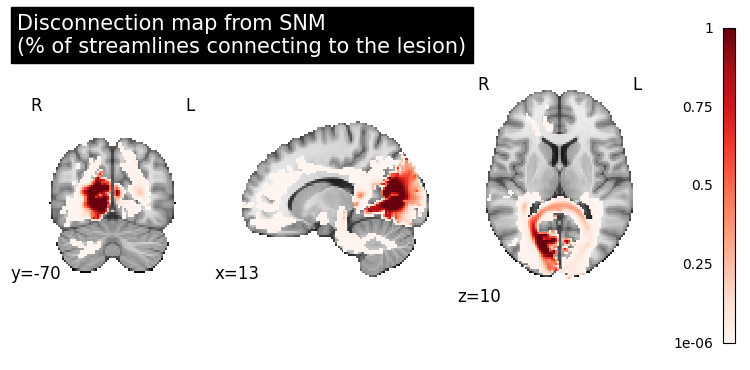

In [8]:
import nibabel as nib
from nilearn import plotting

disconnection_path = '/tmp/outputs_snm_run1/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_method-snm_space-MNI152NLin6Asym_desc-disconnectionpct.nii.gz'
disconnection_img = nib.load(disconnection_path)

disconnection_map = plotting.plot_stat_map(disconnection_img, 
                       radiological=True, 
                       title="Disconnection map from SNM \n(% of streamlines connecting to the lesion)", 
                       draw_cross=False, 
                       colorbar=True,
                       dim=-0.2,
                       cmap='Reds')

## Obtain parcel-level disconnectivity scores and disconnectivity matrix

Beyond voxel-level maps, Lacuna covers two further formats of disconnectivity information: region of interest-level disconnectivity scores and a disconnectivity matrix.

These require the `--compute-roi-disconnection` flag as well as definition of a parcellation atlas via `--parcel-atlases`.

Run the analysis again with these flags.

In [9]:
!lacuna run snm \
    /tmp/tutorial_bids/ \
    /tmp/outputs_snm_run2/ \
    --connectome-path /tmp/dtor985_10pct_data/dtor985_10pct.tck \
    --participant-label 01 \
    --mask-space MNI152NLin6Asym \
    --compute-disconnectivity-matrix \
    --compute-roi-disconnection \
    --parcel-atlases schaefer2018parcels100networks7

Matrix outputs comprise four complementary connectivity representations:
1. Disconnectivity matrix – percentage of streamlines disconnected by the lesion
2. Mask connectivity matrix – number of streamlines traversing the lesion mask
3. Intact connectivity matrix – number of remaining streamlines after excluding those passing through the lesion (i.e., total minus mask connectivity)
4. Full connectome matrix – total number of streamlines irrespective of lesion involvement

In [10]:
!ls /tmp/outputs_snm_run2/sub-01/ses-01/anat/*matrix*

/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-disconnectionpct_connmatrix.json
/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-disconnectionpct_connmatrix.tsv
/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-fullconnectivitymatrix_connmatrix.json
/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-fullconnectivitymatrix_connmatrix.tsv
/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-intactconnectivitymatrix_connmatrix.json
/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-intactconnectivitymatrix_connmatrix.tsv
/tmp/outp

Visualize the disconnectivity of the visual network. Because HCP1065 is mainly consisting of long fiber bundles the sparsity of the matrix is expected.

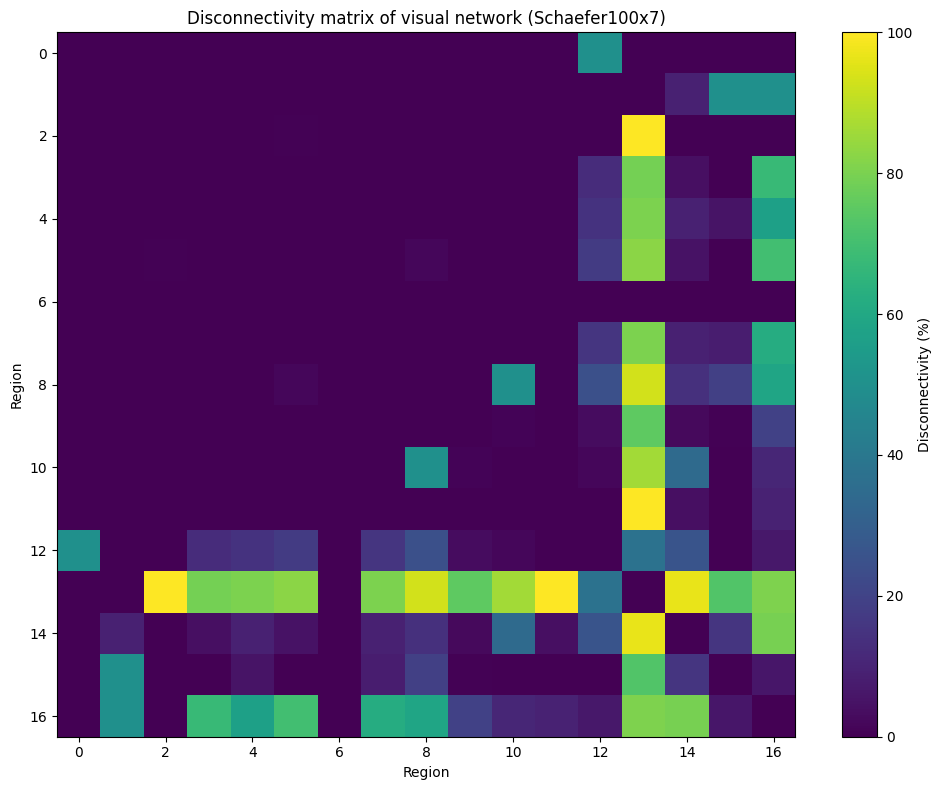

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-disconnectionpct_connmatrix.tsv"
mat = pd.read_csv(file_path, sep="\t", header=0, index_col=0)

visual_network_regions = [parc for parc in mat.index if "Vis" in parc]
mat = mat.loc[visual_network_regions, visual_network_regions]
mat = mat.values

plt.figure(figsize=(10, 8))
im = plt.imshow(mat, aspect='auto')
plt.colorbar(im, label="Disconnectivity (%)")

plt.title("Disconnectivity matrix of visual network (Schaefer100x7)")
plt.xlabel("Region")
plt.ylabel("Region")

im.set_clim(0, 100)

plt.tight_layout()
plt.show()

Visualize the parcel-level disconnection (%) on the cortical surface with [yabplot](https://teanijarv.github.io/yabplot/)

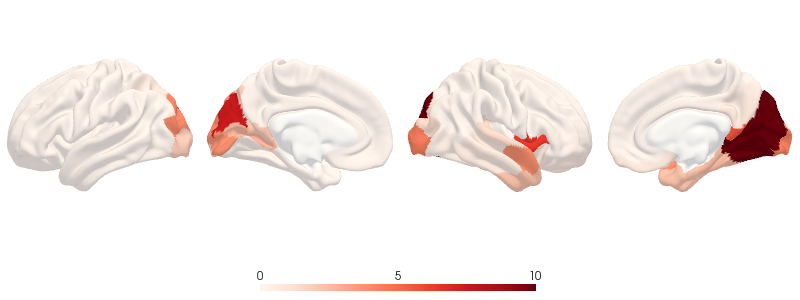

In [12]:
import warnings
import pyvista as pv
import yabplot as yab

warnings.simplefilter("ignore", pv.PyVistaDeprecationWarning)

pv.set_jupyter_backend('static')
pv.global_theme.notebook = True
pv.start_xvfb()

file_path = "/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-disconnectionpct_parcelstats.tsv"

df = pd.read_csv(file_path, sep="\t", index_col=0)
values = df.values.flatten()

yab.plot_cortical(
    data=values,
    atlas='schaefer100',
    views=['left_lateral', 'left_medial', 'right_lateral', 'right_medial'],
    figsize=(800, 300),
    vminmax=(0,10),
    cmap="Reds",
    display_type="static",
)

## Run structural network mapping on multiple subjects
Lacuna supports processing multiple subjects within a single run. If the --participant-label flag is omitted, the analysis is automatically executed for all subjects detected in the BIDS dataset. With the `--verbose` we can see which masks are detected.

Execution strategies are optimized internally for each analysis type. For structural network mapping, subjects are processed sequentially. Parallelizing across subjects is intentionally avoided, as concurrent processes would repeatedly access the same tractogram file, leading to race conditions and degraded performance.

Instead, parallelism is implemented at the single-subject level via multithreading, controlled by the `--nprocs` parameter.



In [13]:
!lacuna run snm \
    /tmp/tutorial_bids/ \
    /tmp/outputs_snm_run3/ \
    --connectome-path /tmp/dtor985_10pct_data/dtor985_10pct.tck \
    --mask-space MNI152NLin6Asym \
    --compute-roi-disconnection \
    --parcel-atlases schaefer2018parcels100networks7 \
    --nprocs 12 \
    --verbose

2026-06-11 14:24:26 - lacuna.cli.main - INFO - Lacuna CLI starting
2026-06-11 14:24:26 - lacuna.cli.main - INFO - Input: /tmp/tutorial_bids
2026-06-11 14:24:26 - lacuna.cli.main - INFO - Output directory: /tmp/outputs_snm_run3
2026-06-11 14:24:26 - lacuna.cli.main - INFO - Analysis: snm
2026-06-11 14:24:26 - lacuna.cli.main - INFO - Registering structural connectome: dtor985_10pct.tck
2026-06-11 14:24:26 - lacuna.cli.main - INFO - Running analysis: StructuralNetworkMapping
2026-06-11 14:24:28 - lacuna.cli.main - INFO - 
2026-06-11 14:24:28 - lacuna.cli.main - INFO - ============================================================
2026-06-11 14:24:28 - lacuna.cli.main - INFO - DISCOVERY SUMMARY
2026-06-11 14:24:28 - lacuna.cli.main - INFO - ============================================================
2026-06-11 14:24:28 - lacuna.cli.main - INFO -   Total mask images: 3
2026-06-11 14:24:28 - lacuna.cli.main - INFO -   Unique subjects:   3
2026-06-11 14:24:28 - lacuna.cli.main - INFO -   Uniq

List the parcel-level outputs for multiple subjects

In [ ]:
!ls /tmp/outputs_snm_run3/sub-*/*/*/sub-*_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-disconnectionpct_parcelstats.tsv

/tmp/outputs_snm_run3/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-disconnectionpct_parcelstats.tsv
/tmp/outputs_snm_run3/sub-02/ses-01/anat/sub-02_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-disconnectionpct_parcelstats.tsv
/tmp/outputs_snm_run3/sub-03/ses-01/anat/sub-03_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-disconnectionpct_parcelstats.tsv


Collect parcel-level outputs into a single tsv

In [22]:
!lacuna collect \
    /tmp/outputs_snm_run3/ \
    --pattern "*disconnectionpct*" \
    --output-dir /tmp/group_outputs/ \
    --verbose

2026-06-11 15:08:21 - lacuna.cli.main - INFO - Running collect (group-level aggregation)
2026-06-11 15:08:21 - lacuna.cli.main - INFO - Scanning derivatives directory: /tmp/outputs_snm_run3
2026-06-11 15:08:21 - lacuna.cli.main - INFO - Output directory: /tmp/group_outputs
2026-06-11 15:08:21 - lacuna.cli.main - INFO - Pattern: *disconnectionpct*_parcelstats.tsv
2026-06-11 15:08:21 - lacuna.cli.main - INFO - Found 3 file(s) across 3 subject(s) and 1 output type(s)
  Reading ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100netwo
2026-06-11 15:08:21 - lacuna.cli.main - INFO - Created 1 group-level TSV file(s):
2026-06-11 15:08:21 - lacuna.cli.main - INFO -   - group_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-disconnectionpct_parcelstats.tsv


In [28]:
!ls /tmp/group_outputs/*disconnectionpct*

/tmp/group_outputs/group_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-disconnectionpct_parcelstats.json
/tmp/group_outputs/group_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-disconnectionpct_parcelstats.tsv


In [25]:
parcel_df = pd.read_csv("/tmp/group_outputs/group_ses-01_label-acuteinfarct_method-snm_atlas-schaefer2018parcels100networks7_desc-disconnectionpct_parcelstats.tsv", sep="\t", index_col=0)
parcel_df

,session_id,label,7Networks_LH_Vis_1,7Networks_LH_Vis_2,7Networks_LH_Vis_3,7Networks_LH_Vis_4,7Networks_LH_Vis_5,7Networks_LH_Vis_6,7Networks_LH_Vis_7,7Networks_LH_Vis_8,...,7Networks_RH_Default_Temp_1,7Networks_RH_Default_Temp_2,7Networks_RH_Default_Temp_3,7Networks_RH_Default_PFCv_1,7Networks_RH_Default_PFCv_2,7Networks_RH_Default_PFCdPFCm_1,7Networks_RH_Default_PFCdPFCm_2,7Networks_RH_Default_PFCdPFCm_3,7Networks_RH_Default_pCunPCC_1,7Networks_RH_Default_pCunPCC_2
participant_id,,,,,,,,,,,,,,,,,,,,,
1,1,acuteinfarct,0.016247,0.077709,0.233209,1.749715,3.693629,2.481182,0.0,3.935833,...,0.507505,3.757325,0.575590,0.539811,0.000000,0.067381,0.014714,0.000000,5.475963,0.521447
2,1,acuteinfarct,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,1,acuteinfarct,0.016247,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.012435,...,13.270705,18.717684,26.676847,0.202429,0.229387,0.000000,0.011035,0.018963,0.366125,0.016821
